Integrantes:

Matías Díaz

Gerardo González

#Cargar el dataset



In [2]:
import pandas as pd #Manejo de tablas de datos
import numpy as np #Operaciones matematicas
import matplotlib.pyplot as plt ## Graficos bonitos
import seaborn as sns # Graficos Bonitos
from sklearn.linear_model import LinearRegression #Modelo de regresion lineal
#funciones para medir qué tan bien predice el modelo
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_excel("df_sub_lol.xlsx")

Se importan las librerías necesarias para el análisis, pandas para el manejo de las tablas de datos, numpy, para el cálculo de datos, matplotlib y seaborn para la creación de gráficos, sklearn ayuda con la modelación lineal, y con las predicciones.

##Revisar la estructura del dataframe.

In [3]:
df.head()

,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,blueHeralds,blueTowersDestroyed,blueTotalGold,blueAvgLevel,blueTotalExperience,blueTotalMinionsKilled,blueTotalJungleMinionsKilled
0,0,28.0,2,1,9,6,11.0,0,0,0,0.0,17210,6.6,17039,195.0,36
1,0,12.0,1,0,5,5,5.0,0,0,0,0.0,14712,6.6,16265,174.0,43
2,0,15.0,0,0,7,11,4.0,1,1,0,0.0,16113,6.4,16221,186.0,46
3,0,43.0,1,0,4,5,5.0,1,0,1,NaN,15157,7.0,17954,201.0,55
4,0,75.0,4,0,6,6,NaN,0,0,0,0.0,16400,7.0,18543,210.0,57


##Creamos una tabla resumen

In [4]:
resumen = pd.DataFrame({
    "Tipo": df.dtypes,
    "Nulos": df.isnull().sum(),
    "% Nulos": (df.isnull().sum() / len(df) * 100).round(2),
    "Mediana": df.median(numeric_only=True)
})
resumen

,Tipo,Nulos,% Nulos,Mediana
blueWins,int64,0,0.00,0.0
blueWardsPlaced,float64,399,4.04,16.0
blueWardsDestroyed,int64,0,0.00,3.0
blueFirstBlood,int64,0,0.00,1.0
blueKills,int64,0,0.00,6.0
blueDeaths,int64,0,0.00,6.0
blueAssists,float64,431,4.36,6.0
blueEliteMonsters,int64,0,0.00,0.0
blueDragons,int64,0,0.00,0.0
blueHeralds,int64,0,0.00,0.0


In [5]:
df.describe().round(2)

,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,blueHeralds,blueTowersDestroyed,blueTotalGold,blueAvgLevel,blueTotalExperience,blueTotalMinionsKilled,blueTotalJungleMinionsKilled
count,9879.0,9480.00,9879.00,9879.0,9879.00,9879.00,9448.00,9879.00,9879.00,9879.00,9484.00,9879.00,9425.00,9879.00,9047.00,9879.00
mean,0.5,22.28,2.82,0.5,6.18,6.14,6.64,0.55,0.36,0.19,0.05,16503.46,6.92,17928.11,216.69,50.51
std,0.5,17.99,2.17,0.5,3.01,2.93,4.06,0.63,0.48,0.39,0.24,1535.45,0.31,1200.52,21.85,9.90
min,0.0,5.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,10730.00,4.60,10098.00,90.00,0.00
25%,0.0,14.00,1.00,0.0,4.00,4.00,4.00,0.00,0.00,0.00,0.00,15415.50,6.80,17168.00,202.00,44.00
50%,0.0,16.00,3.00,1.0,6.00,6.00,6.00,0.00,0.00,0.00,0.00,16398.00,7.00,17951.00,218.00,50.00
75%,1.0,20.00,4.00,1.0,8.00,8.00,9.00,1.00,1.00,0.00,0.00,17459.00,7.20,18724.00,232.00,56.00
max,1.0,250.00,27.00,1.0,22.00,22.00,29.00,2.00,1.00,1.00,4.00,23701.00,8.00,22224.00,283.00,92.00


##Cantidad de filas y de columnas

In [6]:
df.shape

(9879, 16)

##Selecion de variables


Se selecciona la variable blueTotalMinionsKilled como la variable de tipo independiente (x), y la variable dependiente (y) blueTotalGold, debido a que los minions son una de las principales fuentes de oro, por lo tanto, blueTotalMinionsKilled puede actuar como un buen predictor de blueTotalGold, lo que hace coherente su uso en un modelo de regresión lineal.

##Imputacion por la mediana

In [7]:
# Imputación de nulos con la mediana
df["blueTotalMinionsKilled"] = df["blueTotalMinionsKilled"].fillna(df["blueTotalMinionsKilled"].median())
print(f"Nulos restantes: {df['blueTotalMinionsKilled'].isnull().sum()}")

Nulos restantes: 0


In [8]:
df_clean = df[['blueTotalMinionsKilled', 'blueTotalGold']]

La columna blueTotalMinionsKilled tiene 832 valores nulos.
Se imputan con la mediana (218) para conservar todas las
filas en lugar de eliminarlas.

##Cantida de valores nulos despues de la limpieza (0);

In [9]:
resumen = pd.DataFrame({
    "Tipo": df_clean.dtypes,
    "Nulos": df_clean.isnull().sum(),
    "% Nulos": (df_clean.isnull().sum() / len(df) * 100).round(2)
})

resumen

,Tipo,Nulos,% Nulos
blueTotalMinionsKilled,float64,0,0.0
blueTotalGold,int64,0,0.0


##Graficamos las variables seleccionadas


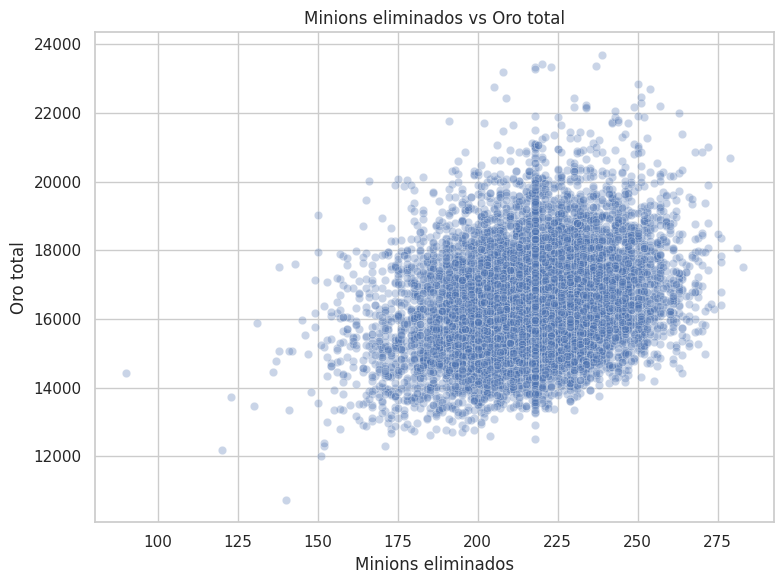

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")#fondo blanco con cuadricula
plt.figure(figsize=(8,6))#tamaño del grafico
sns.scatterplot(data=df_clean, x="blueTotalMinionsKilled", y="blueTotalGold", alpha=0.3)#Dibujo de los puntos del grafico
plt.title("Minions eliminados vs Oro total")#Titulo del grafico
plt.xlabel("Minions eliminados")#ejex
plt.ylabel("Oro total")#ejey
plt.tight_layout()#Ajusta el marge
plt.show()#muestra el grafico

Como se observa en la imagen, existe una relación entre las variables x e y, debido a que los puntos presentan una tendencia ascendente, lo que indica una relación positiva. Esto implica que, a medida que aumenta la cantidad de minions asesinados, también aumenta la cantidad de oro total.

No obstante, la relación observada es débil, debido a la alta variabilidad de los datos, y la imagen no representa una grafico ligeramente lineal.

##Analizamos la correlación de las variables

In [11]:
correlacion = df_clean["blueTotalMinionsKilled"].corr(df_clean["blueTotalGold"])
print(correlacion)

0.2682955591105972


Se encontró una relación positiva pero débil entre los
minions eliminados y el oro total, la correlación es de 0.26
lo que nos dice  que a mayor cantidad de minions asesinados, el oro aumentar un poco, pero no en una gran medida.

In [12]:
X = df_clean[["blueTotalMinionsKilled"]]#Guarda la variable independiente que es la cantidad de minions asesinados
y = df_clean["blueTotalGold"]#Guarda la variable dependiente de la canridad de oro obtenido

X es la variable independiente: blueTotalMinionsKilled, minions asesinados

Y es la variable dependiente: blueTotalGold, oro total obtenido

Se busca predecir el oro total en relacion de
los minions asesinados.

##Creación del modelo de regresión lineal


In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()#Se crea el modelo de regresion lineal
model.fit(X, y)#Estudio de la relacion de los minions y del oro

slope = model.coef_[0]#Guarda la pendiende es decir cuanto sube el oro por cantidad de minion
intercept = model.intercept_#Guarda el intercepto, el valor del oro cuando los minions es de 0
print(f"Pendiente: {slope:.2f}")#Muestra la pendiente con 2 deciamales
print(f"Intercepto: {intercept:.2f}")#muestra el intercepto con dos decimales

y_pred = model.predict(X)#Usa el modela entrenado para realizar la prediccion

Pendiente: 19.70
Intercepto: 12232.83


##Análisis del modelo de regresión lineal

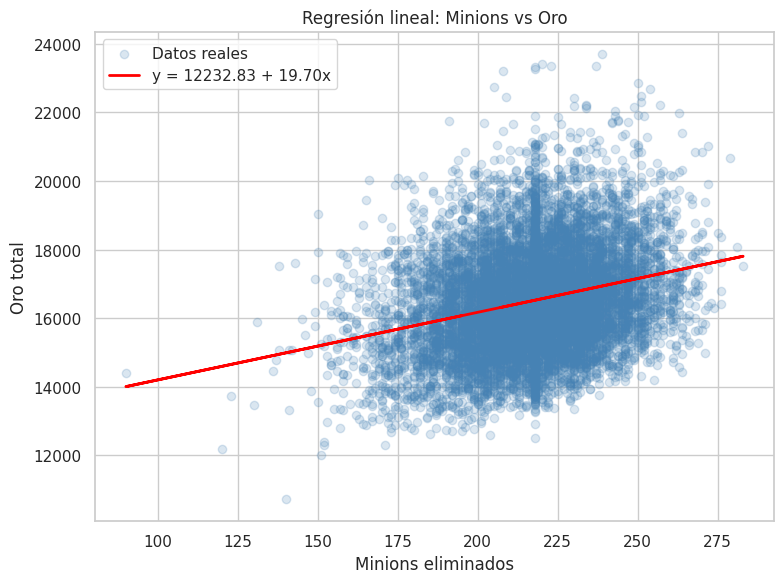

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(X, y, alpha=0.2, color="steelblue", label="Datos reales")#puntos
plt.plot(X, y_pred, color="red", linewidth=2, label=f"y = {intercept:.2f} + {slope:.2f}x")#linea
plt.title("Regresión lineal: Minions vs Oro")
plt.xlabel("Minions eliminados")
plt.ylabel("Oro total")
plt.legend()
plt.tight_layout()
plt.show()

Con esto se obtienen los datos:

y = 12232.83 + 19.70x

b0 = 12232.83 es el intercepto, representa el oro base desde el inicio de la partida cuando la cantidad de minions es de 0.

b1 = 19.70 es la pendiente, por cada minion asesinado se obtiene 19.70 de oro adicional.

In [15]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse  = mean_squared_error(y, y_pred)#calcula el promedio de los errores al cuadrado entre los valores reales y las predicciones
rmse = np.sqrt(mse)#saca la raíz cuadrada del MSE para que el error quede en la misma unidad que el oro
mae  = mean_absolute_error(y, y_pred)#calcula el promedio de cuánto se equivoca el modelo sin importar si es para arriba o para abajo
r2   = r2_score(y, y_pred)# calcula qué porcentaje de la variación del oro explica el modelo

import pandas as pd
pd.DataFrame({"MSE":[mse], "RMSE":[rmse], "MAE":[mae], "R²":[r2]})

,MSE,RMSE,MAE,R²
0,2.187669e+06,1479.077147,1174.973823,0.071983


MSE: 2.187669e+06 : El promedio del error al cuadrado

RMSE: 1479 : En promedio, el modelo se equivoca en 1479 unidades de oro por partida

MAE: 1174 : El modelo se equivoca en promedio 1174 unidades de oro ( diferencia del RMSE, es menos sensible a errores grandes.)

R²: 0.071 : El modelo solo explica el 7.1% de la variación del oro, lo que indica que el modelo es débil

##Interpretación

El análisis realizado evidencia la existencia de una relación positiva entre las variables blueTotalMinionsKilled y blueTotalGold, lo que indica que, en general, a medida que aumenta la cantidad de minions eliminados, también tiende a incrementarse el oro total acumulado. Sin embargo, esta relación es débil, ya que los datos presentan una alta dispersión.

En este sentido, la recta de regresión no representa adecuadamente el comportamiento de los datos, debido a que no logra ajustarse con precisión a la variabilidad observada en el gráfico.

Las métricas obtenidas refuerzan esta interpretación: el valor de R² (0.071) indica que el modelo explica solo el 7.1% de la variación del oro, lo que evidencia un ajuste débil. Asimismo, los valores de error (RMSE y MAE) muestran que las predicciones presentan diferencias considerables respecto a los valores reales.

Desde un punto de vista práctico, el modelo tiene una utilidad limitada, ya que no permite realizar predicciones precisas del oro total basándose únicamente en la cantidad de minions eliminados.

Finalmente, una de las principales limitaciones de este análisis es que considera solo una variable explicativa, cuando en realidad el oro total depende de múltiples factores, como asesinatos, objetivos (dragones, torres), asistencias y otros elementos del juego. Por ello, sería recomendable incorporar más variables en un modelo multivariable para mejorar la capacidad predictiva.